# Olist E-Commerce Data Understanding

This notebook presents an initial exploration of the Olist Brazilian E-Commerce dataset by examining the structure, dimensions, variables, and relationships among its tables.

The primary objective of this project is to gain a comprehensive understanding of the dataset as a foundation for subsequent data preprocessing and feature engineering tasks. In later stages, the project will focus on customer behavior analysis, customer segmentation, retention analysis, customer lifetime value (CLV) estimation, and the development of machine learning models for customer intelligence.This notebook represents the first phase of an end-to-end customer intelligence pipeline.

## Table of Contents

- [Dataset Overview](#1-dataset-overview)
- [Data Types](#2-data-types)
- [Missing Values](#3-missing-values)
- [Duplicate Records](#4-duplicate-records)
- [Summary Statistics](#5-summary-statistics)
- [Dataset Information](#6-dataset-information)
- [Unique Values](#7-unique-values)
- [Memory Usage](#8-memory-usage)
- [Numerical Feature Distribution](#9-numerical-feature-distribution)
- [Correlation Analysis](#10-correlation-analysis)
- [Dataset Relationships](#11-dataset-relationships)
- [Data Quality Assessment](#12-data-quality-assessment)
- [Conclusion](#13-conclusion)

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
DATA_PATH = Path("../data")

customers = pd.read_csv(DATA_PATH / "olist_customers_dataset.csv")
orders = pd.read_csv(DATA_PATH / "olist_orders_dataset.csv")
order_items = pd.read_csv(DATA_PATH / "olist_order_items_dataset.csv")
payments = pd.read_csv(DATA_PATH / "olist_order_payments_dataset.csv")
reviews = pd.read_csv(DATA_PATH / "olist_order_reviews_dataset.csv")
products = pd.read_csv(DATA_PATH / "olist_products_dataset.csv")
sellers = pd.read_csv(DATA_PATH / "olist_sellers_dataset.csv")
geolocation = pd.read_csv(DATA_PATH / "olist_geolocation_dataset.csv")
category_translation = pd.read_csv(
    DATA_PATH / "product_category_name_translation.csv"
)

In [3]:
datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "geolocation": geolocation,
    "category_translation": category_translation
}

for name, dataframe in datasets.items():
    print(f"{name}: {dataframe.shape[0]} satır, {dataframe.shape[1]} sütun")

customers: 99441 satır, 5 sütun
orders: 99441 satır, 8 sütun
order_items: 112650 satır, 7 sütun
payments: 103886 satır, 5 sütun
reviews: 99224 satır, 7 sütun
products: 32951 satır, 9 sütun
sellers: 3095 satır, 4 sütun
geolocation: 1000163 satır, 5 sütun
category_translation: 71 satır, 2 sütun


## 1. Dataset Overview

This section provides an overview of all tables that comprise the Olist Brazilian E-Commerce dataset.

Each table is examined in terms of its number of rows and columns to gain a comprehensive understanding of the overall structure and scale of the dataset before conducting further analysis.

In [4]:
for name, df in datasets.items():
    print("=" * 50)
    print(name.upper())
    print("=" * 50)
    print(df.head())
    print()

CUSTOMERS
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  

ORDERS
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b

## 2. Data Types

This section examines the data types of all variables in each table.

Understanding the data types of variables is essential for selecting appropriate preprocessing techniques, performing accurate analyses, and ensuring compatibility with machine learning algorithms.

In [5]:
for name, df in datasets.items():
    print(f"\n{name}")
    print(df.dtypes)


customers
customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object

orders
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

order_items
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

payments
order_id                    str
payment_sequential        int64
payment_type                str
payment_installments      int64
payment_value           float64
dtype: object

reviews
review_id                    str
order_id         

## 3. Missing Values

This section examines missing values across the dataset.

Identifying missing data is a crucial step in evaluating data quality and determining appropriate preprocessing techniques before performing further analysis and machine learning tasks.

In [6]:
for name, df in datasets.items():
    print(f"\n{name}")
    print(df.isnull().sum())


customers
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

orders
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

order_items
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

payments
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

reviews
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review

## 4. Duplicate Records

This section examines duplicate records within each table of the dataset.

Identifying duplicate entries is an essential step in assessing data quality and ensuring the reliability of subsequent data preprocessing and machine learning analyses.

In [7]:
for name, df in datasets.items():
    duplicate_count = df.duplicated().sum()

    print(f"{name}: {duplicate_count} duplicate records")

customers: 0 duplicate records
orders: 0 duplicate records
order_items: 0 duplicate records
payments: 0 duplicate records
reviews: 0 duplicate records
products: 0 duplicate records
sellers: 0 duplicate records
geolocation: 261831 duplicate records
category_translation: 0 duplicate records


### Observation

Duplicate records are concentrated in the geolocation dataset, while the remaining tables contain no fully duplicated rows.

The duplicated geolocation records will require dedicated treatment during the data cleaning stage to avoid unnecessary redundancy.

## 5. Summary Statistics

This section presents the descriptive statistical summary of numerical variables.

Key statistical measures, including count, mean, standard deviation, minimum, maximum, and quartile values, are analyzed to better understand the distribution and characteristics of the data.

In [8]:
for name, df in datasets.items():
    print("=" * 60)
    print(name.upper())
    print("=" * 60)

    print(df.describe())

    print()

CUSTOMERS
       customer_zip_code_prefix
count              99441.000000
mean               35137.474583
std                29797.938996
min                 1003.000000
25%                11347.000000
50%                24416.000000
75%                58900.000000
max                99990.000000

ORDERS
                                order_id                       customer_id  \
count                              99441                             99441   
unique                             99441                             99441   
top     e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
freq                                   1                                 1   

       order_status order_purchase_timestamp    order_approved_at  \
count         99441                    99441                99281   
unique            8                    98875                90733   
top       delivered      2018-03-31 15:08:21  2018-02-27 04:31:10   
freq          96478        

## 6. Dataset Information

This section provides general information about each dataset, including the number of entries, data types, non-null values, and memory usage.

Examining this information helps assess the overall structure of the datasets and identify potential issues before further data preprocessing and analysis.

In [9]:
for name, df in datasets.items():
    print("=" * 60)
    print(name.upper())
    print("=" * 60)

    df.info()

    print("\n")

CUSTOMERS
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


ORDERS
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at

## 7. Unique Values

This section examines the number of unique values within categorical variables.

Analyzing the cardinality of categorical features provides insights into the diversity of the data and helps identify variables that may require encoding or further preprocessing during the feature engineering stage.


In [10]:
for name, df in datasets.items():

    print("=" * 60)
    print(name.upper())
    print("=" * 60)

    categorical_columns = df.select_dtypes(include=["object", "string"]).columns

    for column in categorical_columns:
        unique_count = df[column].nunique()
        print(f"{column}: {unique_count} unique values")

    print()

CUSTOMERS
customer_id: 99441 unique values
customer_unique_id: 96096 unique values
customer_city: 4119 unique values
customer_state: 27 unique values

ORDERS
order_id: 99441 unique values
customer_id: 99441 unique values
order_status: 8 unique values
order_purchase_timestamp: 98875 unique values
order_approved_at: 90733 unique values
order_delivered_carrier_date: 81018 unique values
order_delivered_customer_date: 95664 unique values
order_estimated_delivery_date: 459 unique values

ORDER_ITEMS
order_id: 98666 unique values
product_id: 32951 unique values
seller_id: 3095 unique values
shipping_limit_date: 93318 unique values

PAYMENTS
order_id: 99440 unique values
payment_type: 5 unique values

REVIEWS
review_id: 98410 unique values
order_id: 98673 unique values
review_comment_title: 4527 unique values
review_comment_message: 36159 unique values
review_creation_date: 636 unique values
review_answer_timestamp: 98248 unique values

PRODUCTS
product_id: 32951 unique values
product_category

## 8. Memory Usage

This section examines the memory usage of each table in the dataset.

Understanding memory consumption is important for optimizing data processing performance and efficiently handling large-scale datasets during data analysis and machine learning workflows.

In [11]:
for name, df in datasets.items():

    memory = df.memory_usage(deep=True).sum() / 1024**2

    print("=" * 60)
    print(name.upper())
    print("=" * 60)
    print(f"Memory Usage: {memory:.2f} MB")
    print()

CUSTOMERS
Memory Usage: 26.59 MB

ORDERS
Memory Usage: 52.94 MB

ORDER_ITEMS
Memory Usage: 35.99 MB

PAYMENTS
Memory Usage: 16.23 MB

REVIEWS
Memory Usage: 39.12 MB

PRODUCTS
Memory Usage: 6.30 MB

SELLERS
Memory Usage: 0.59 MB

GEOLOCATION
Memory Usage: 130.26 MB

CATEGORY_TRANSLATION
Memory Usage: 0.01 MB



## 9. Numerical Feature Distribution

This section analyzes the distribution of numerical features in the dataset.

Histograms are used to understand the data distribution and identify potential outliers before feature engineering and machine learning.

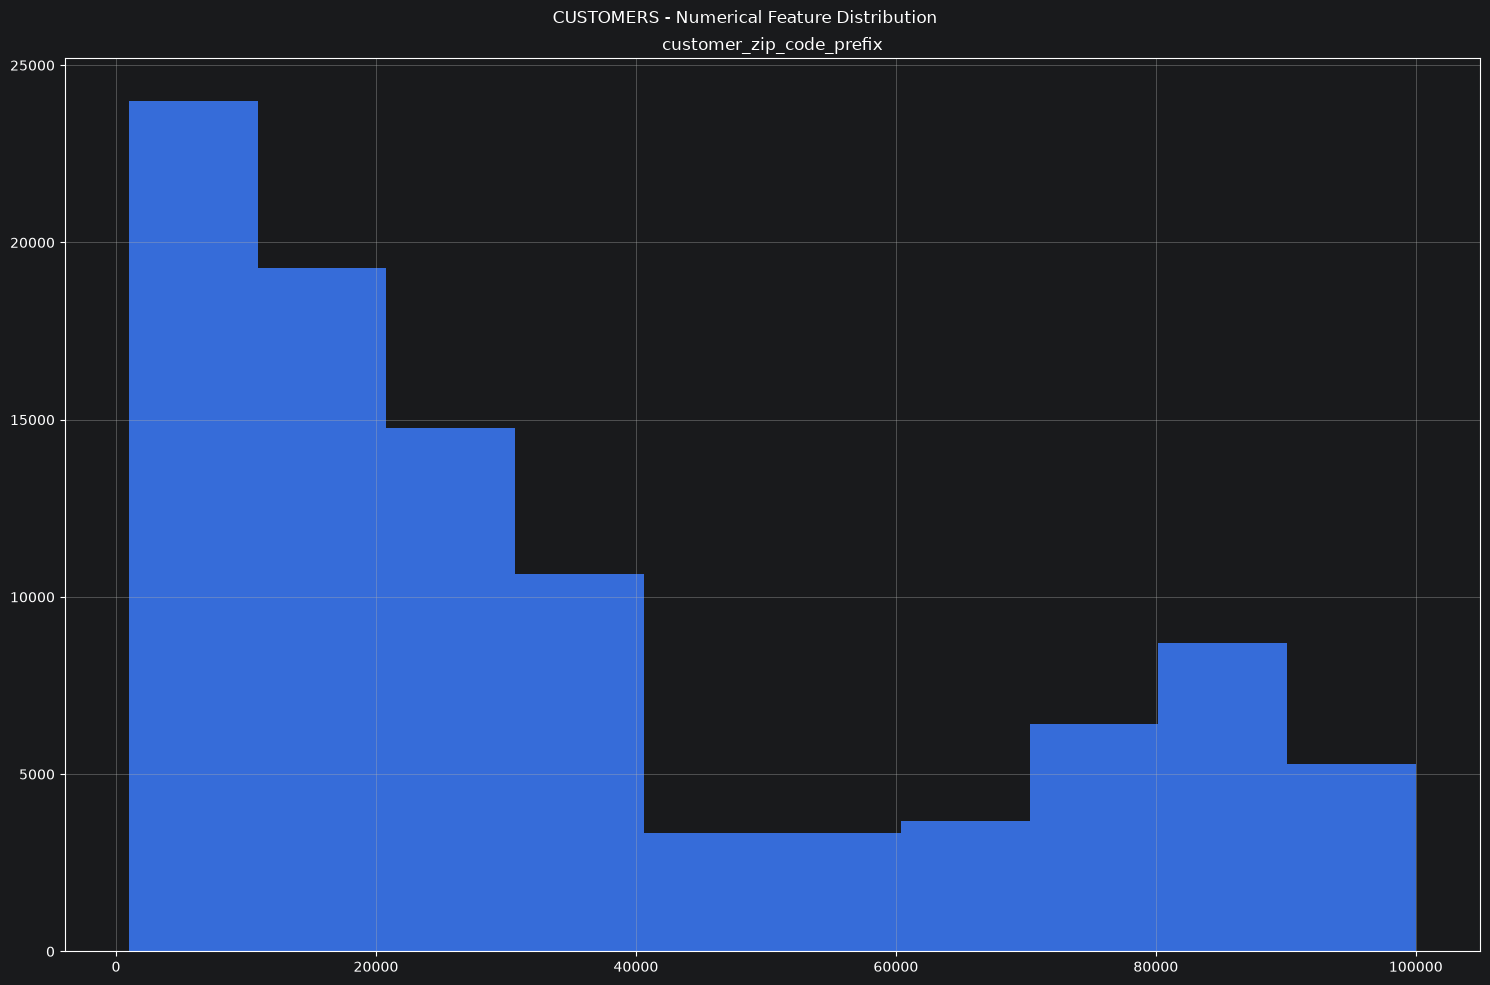

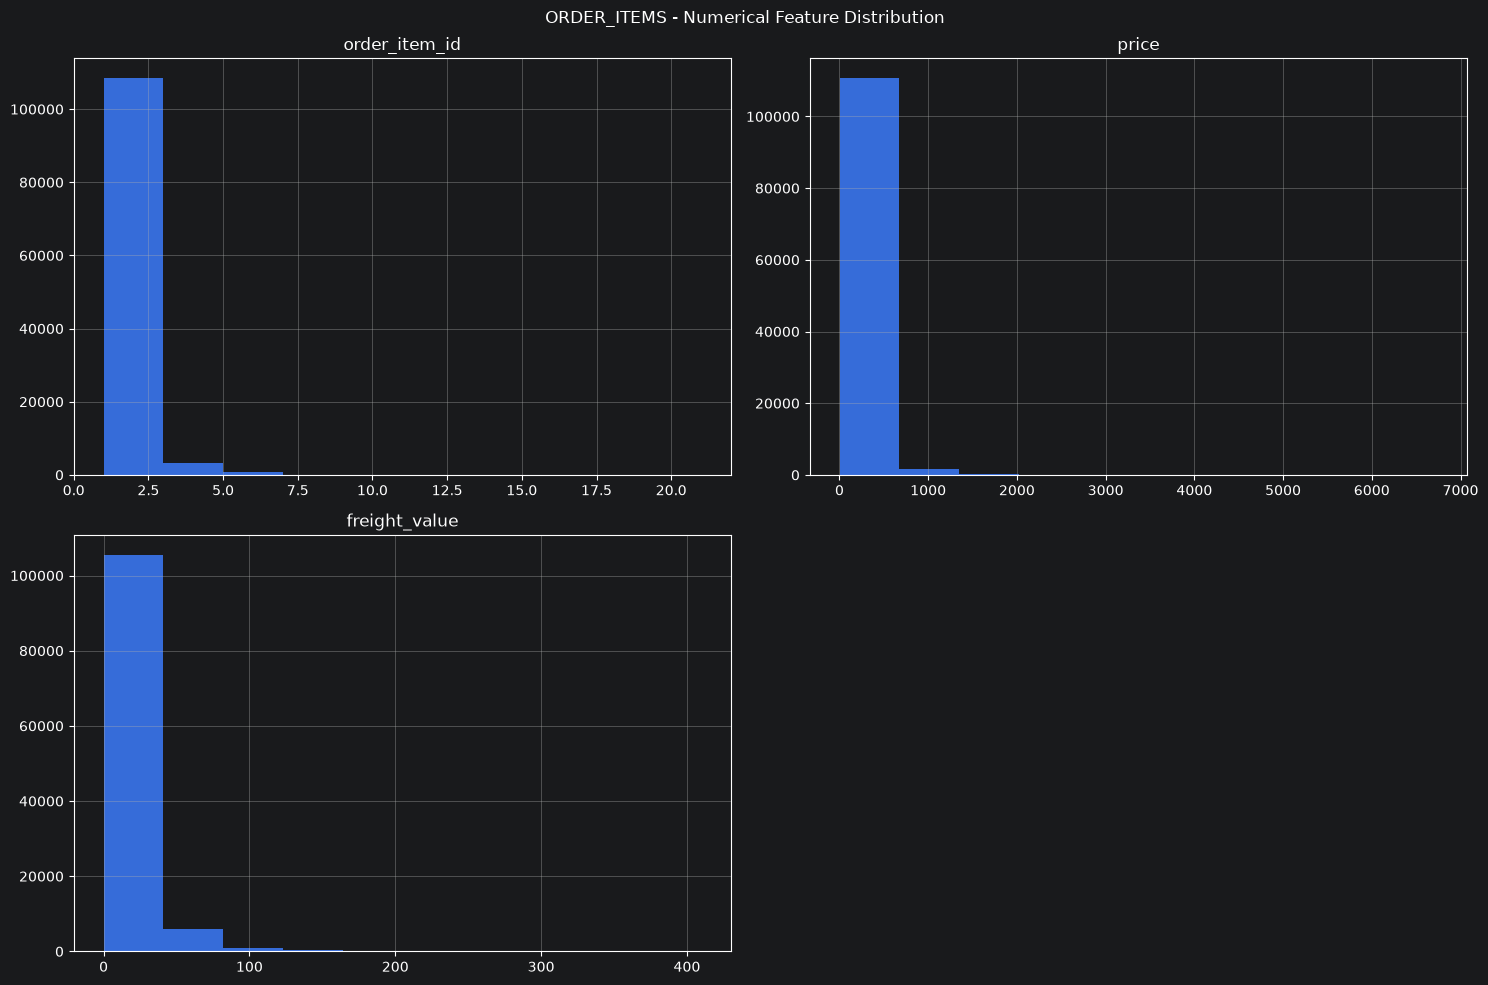

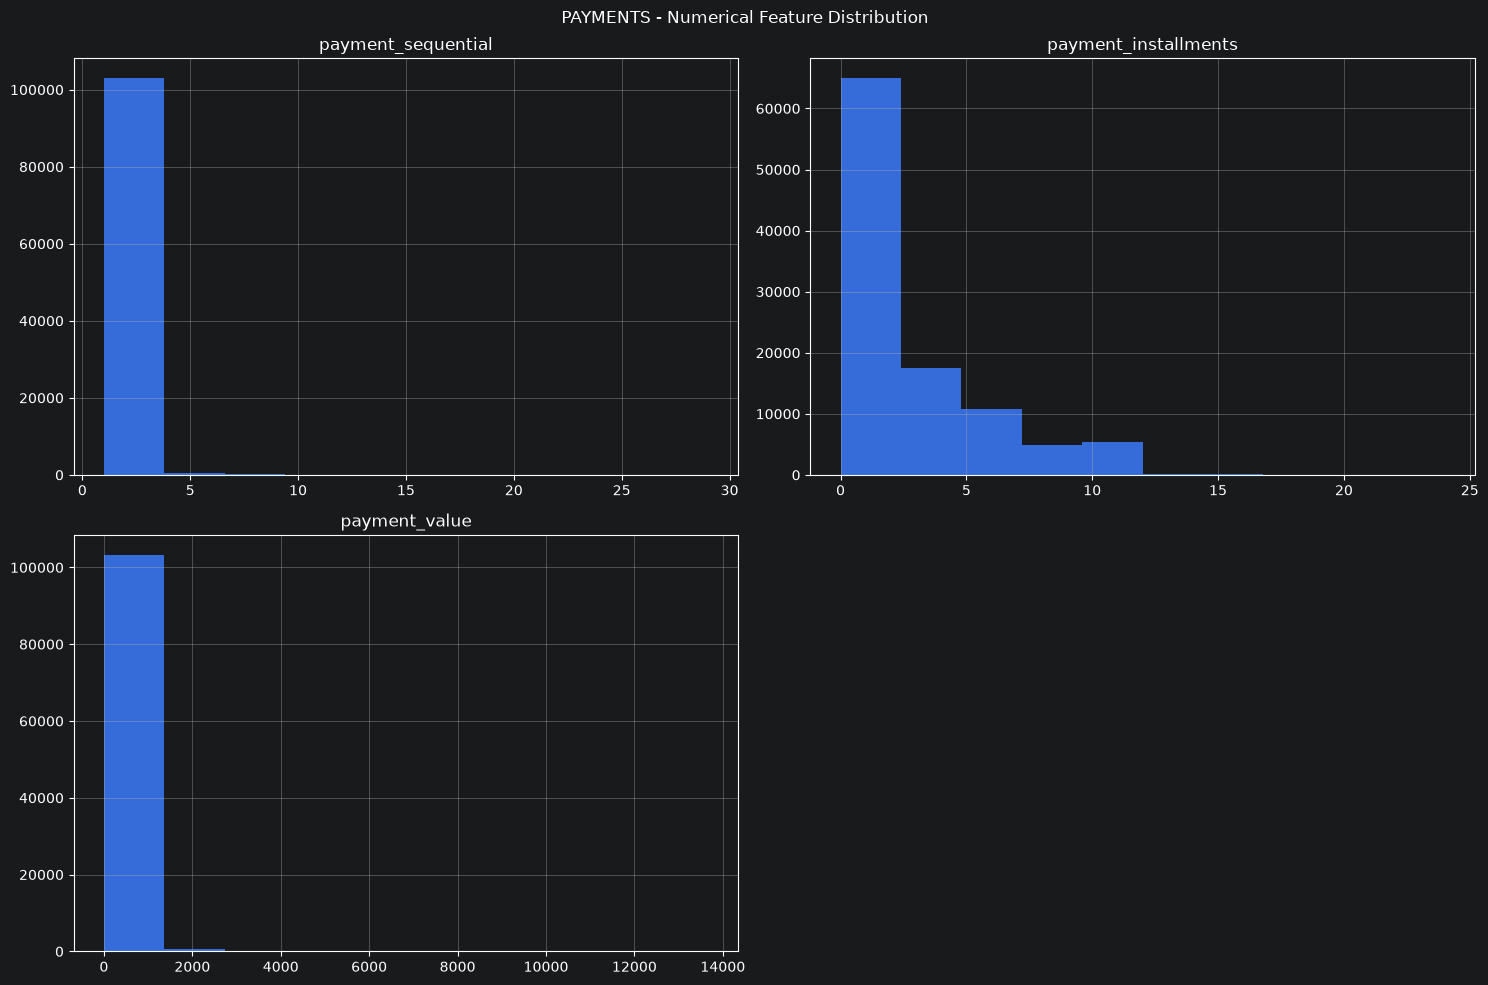

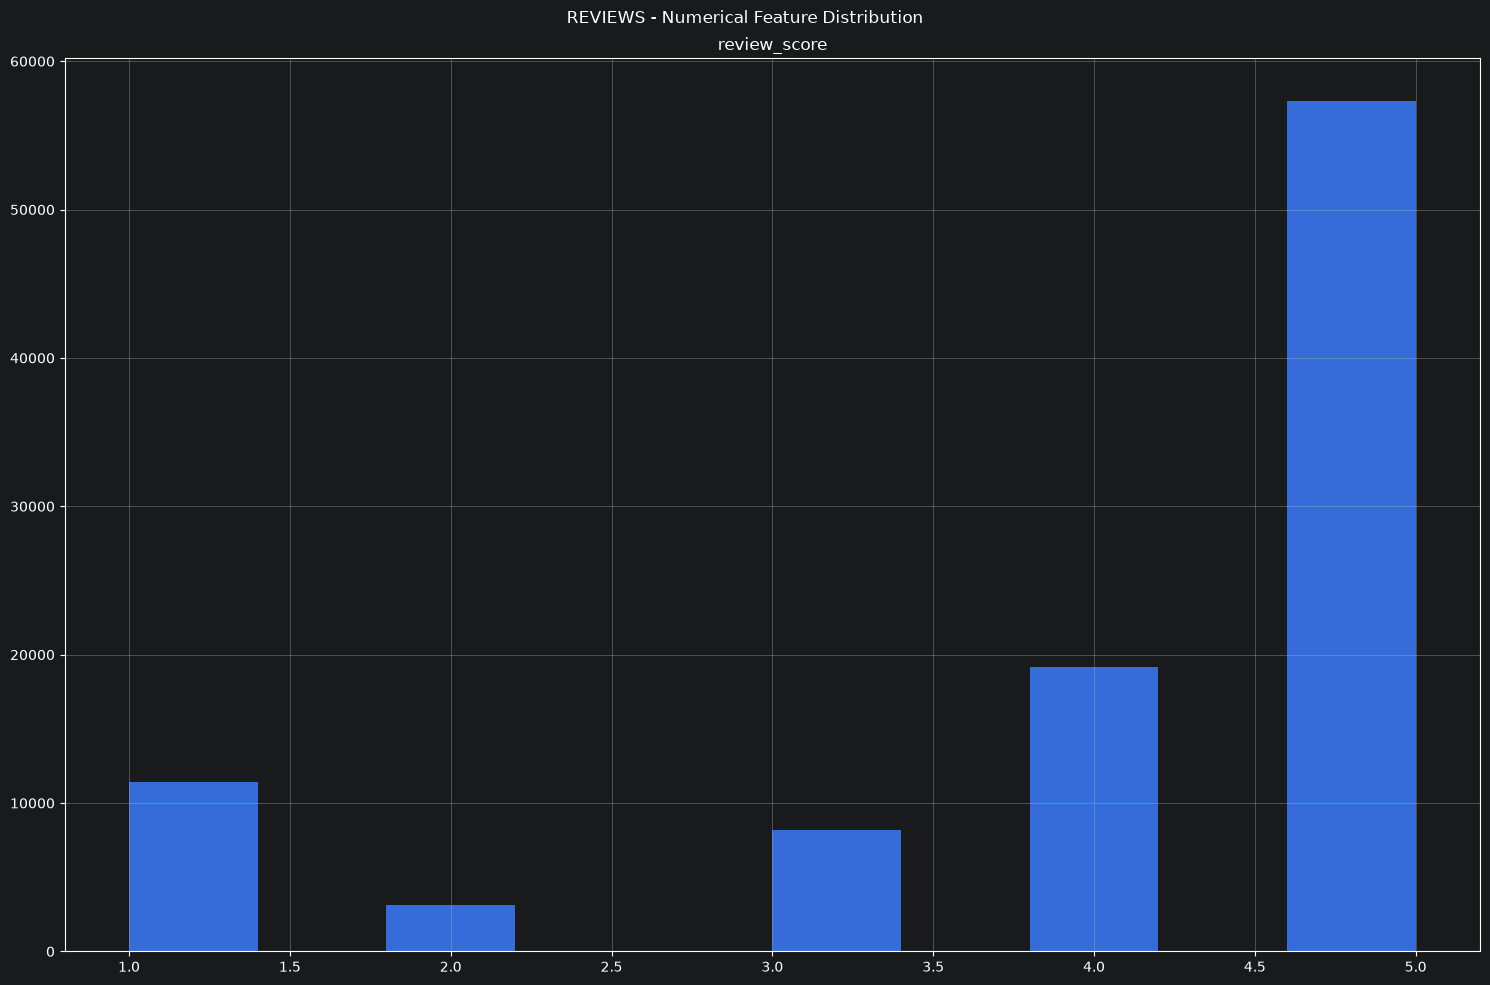

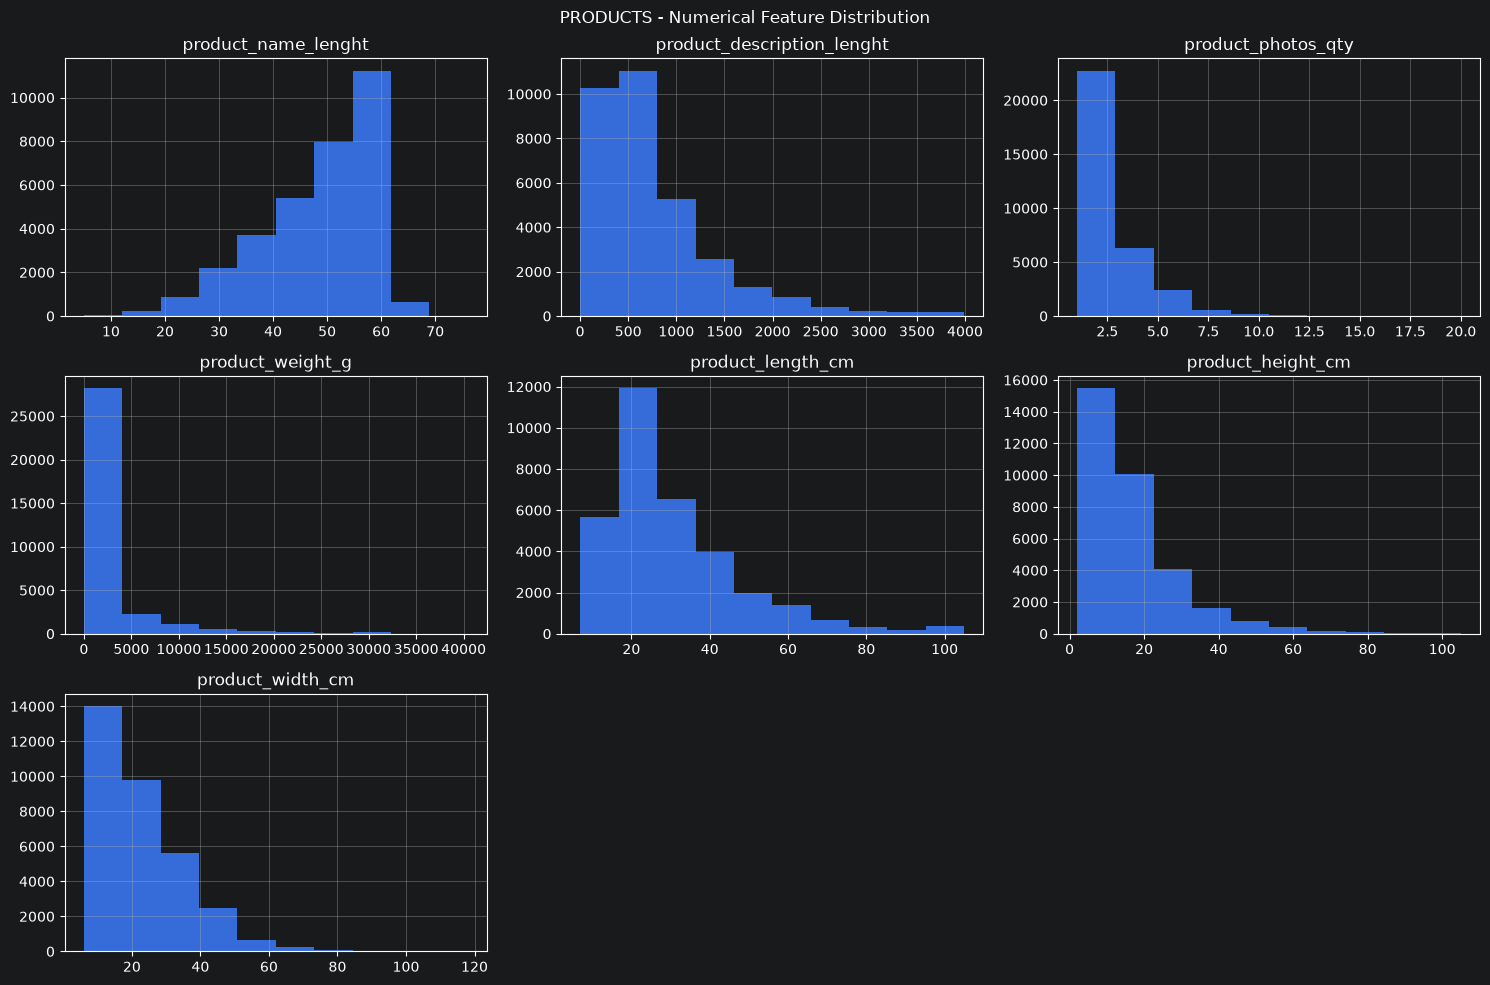

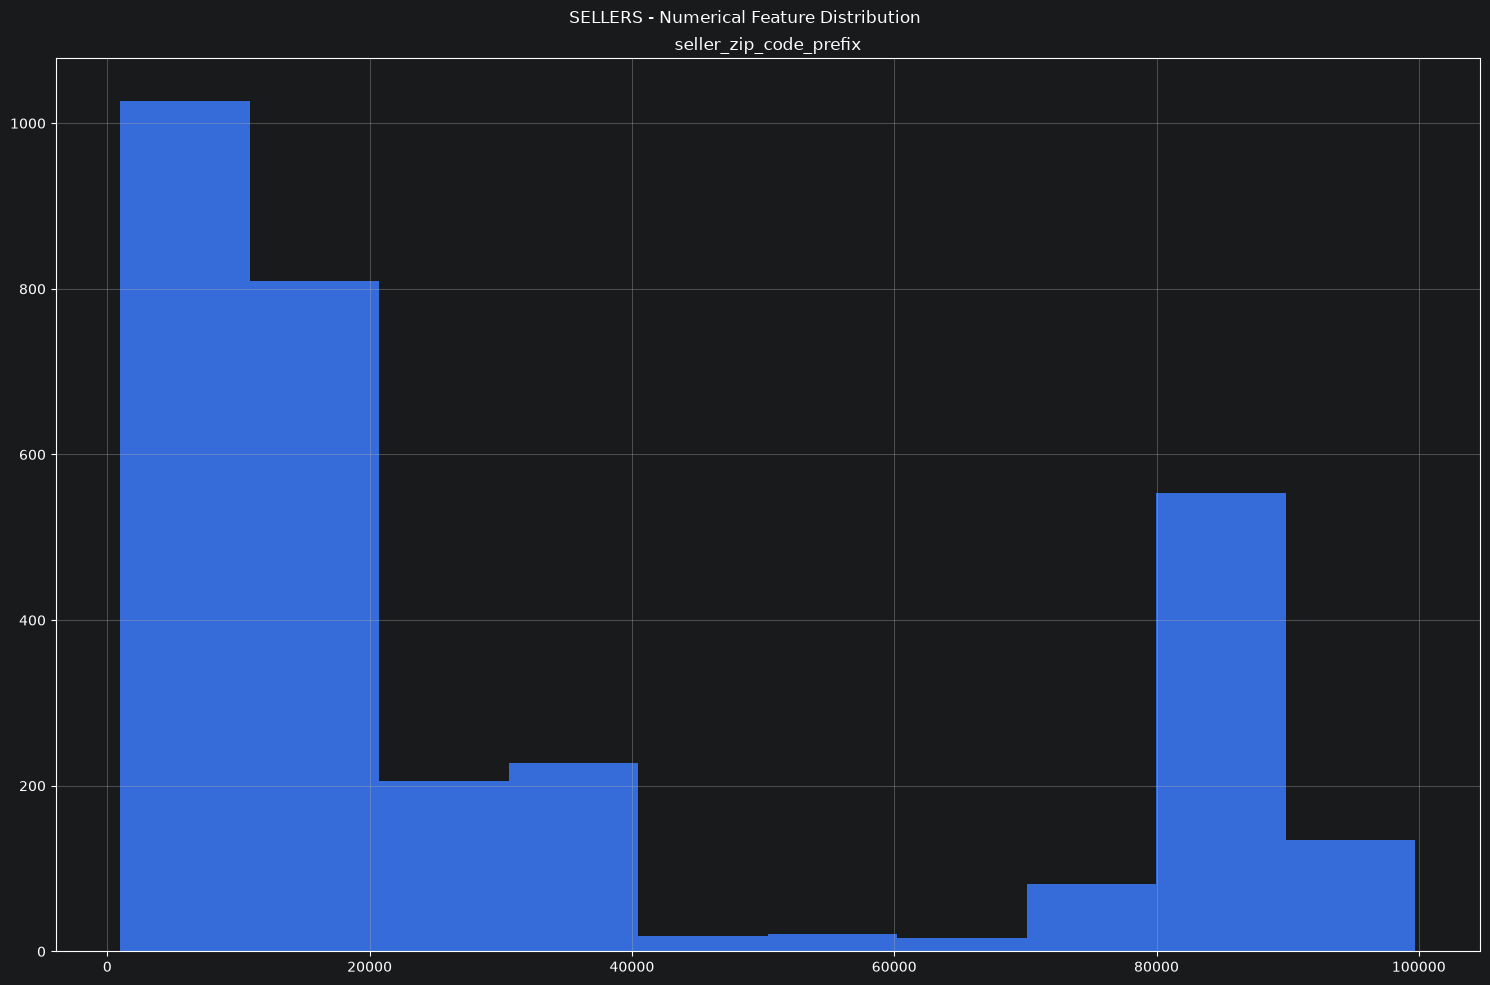

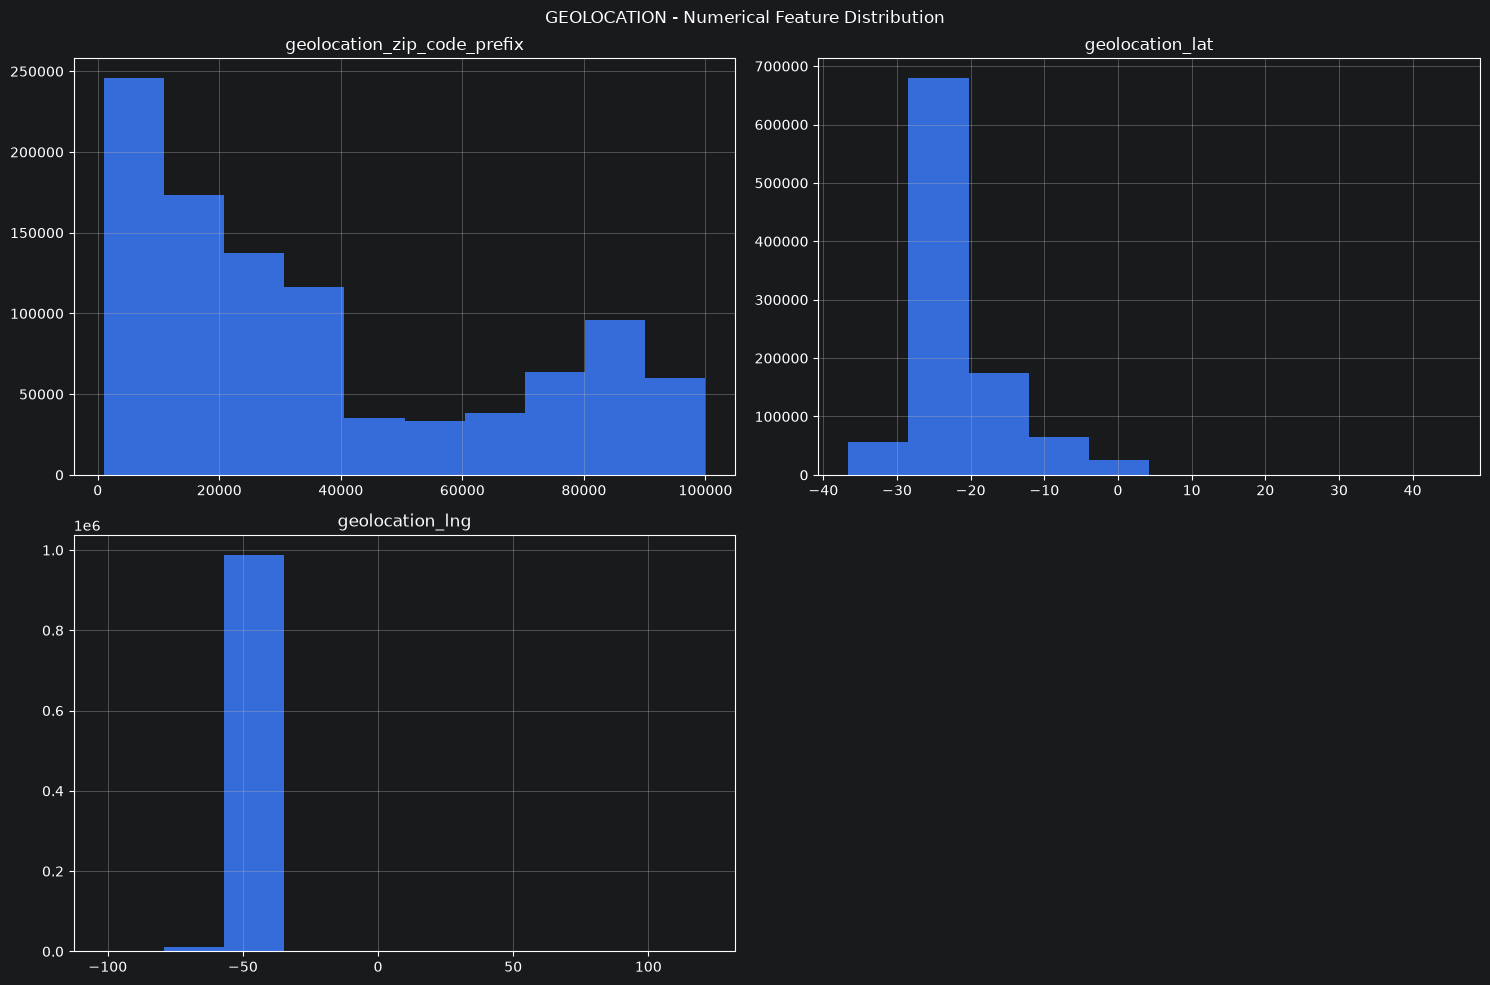

In [12]:
import matplotlib.pyplot as plt

for name, df in datasets.items():

    numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

    if len(numerical_columns) == 0:
        continue

    df[numerical_columns].hist(figsize=(15, 10))
    plt.suptitle(f"{name.upper()} - Numerical Feature Distribution")
    plt.tight_layout()
    plt.show()

## 10. Correlation Analysis

This section examines the relationships between numerical variables using correlation matrices.

Correlation analysis helps identify linear relationships among features and provides valuable insights for feature selection and machine learning model development.

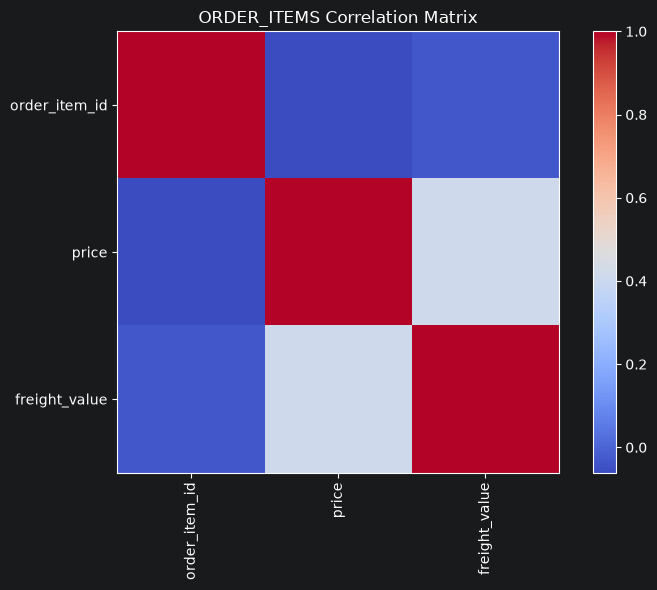

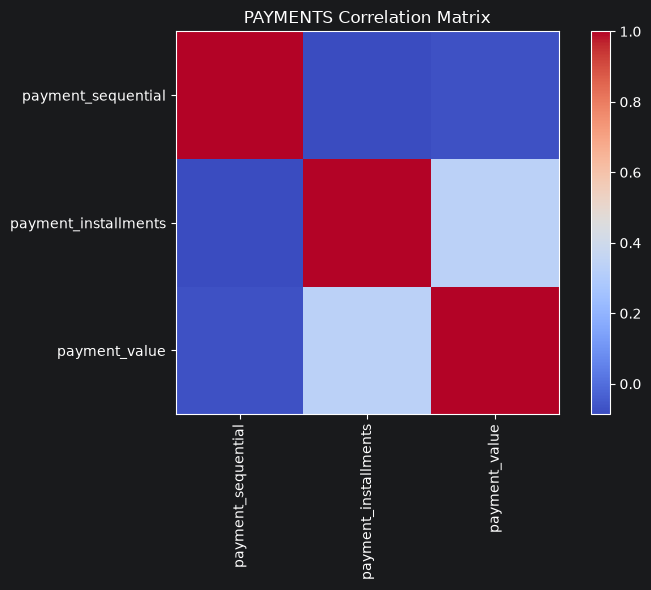

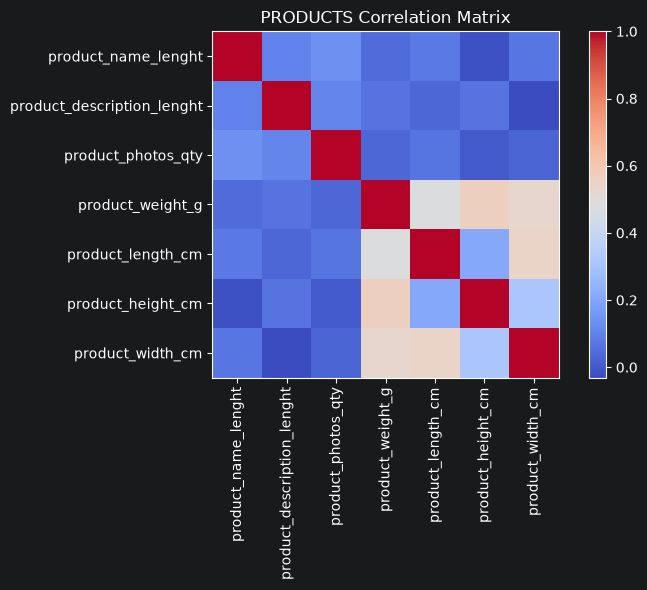

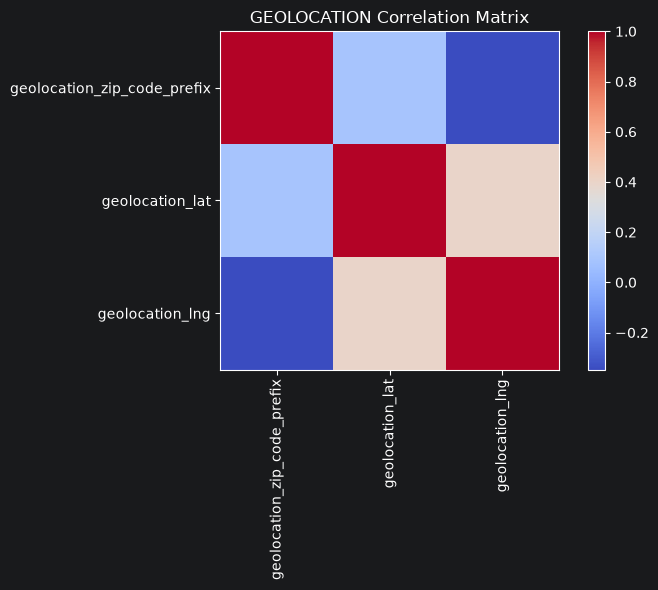

In [13]:
import matplotlib.pyplot as plt

for name, df in datasets.items():

    numerical_columns = df.select_dtypes(include=["int64", "float64"])

    if numerical_columns.shape[1] < 2:
        continue

    correlation = numerical_columns.corr()

    plt.figure(figsize=(8,6))
    plt.imshow(correlation, cmap="coolwarm")
    plt.colorbar()

    plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
    plt.yticks(range(len(correlation.columns)), correlation.columns)

    plt.title(f"{name.upper()} Correlation Matrix")
    plt.tight_layout()
    plt.show()

## 11. Dataset Relationships

The Olist Brazilian E-Commerce dataset consists of multiple relational tables connected through primary and foreign keys.

The **Customers** table is linked to the **Orders** table through `customer_id`. The **Orders** table is connected to the **Order Items**, **Payments**, and **Reviews** tables through `order_id`.

The **Order Items** table establishes relationships with the **Products** and **Sellers** tables using `product_id` and `seller_id`, respectively. In addition, the **Products** table is associated with the **Product Category Translation** table through `product_category_name`.

Understanding these relationships is essential for combining the tables correctly, performing feature engineering, and developing customer-centric machine learning models in the subsequent stages of the project.

In [14]:
relationships = {
    "Customers": ["customer_id"],
    "Orders": ["order_id", "customer_id"],
    "Order Items": ["order_id", "product_id", "seller_id"],
    "Payments": ["order_id"],
    "Reviews": ["order_id"],
    "Products": ["product_id", "product_category_name"],
    "Sellers": ["seller_id"],
    "Product Category Translation": ["product_category_name"]
}

relationship_df = pd.DataFrame(
    [(table, ", ".join(keys)) for table, keys in relationships.items()],
    columns=["Table", "Key Columns"]
)

relationship_df

,Table,Key Columns
0,Customers,customer_id
1,Orders,"order_id, customer_id"
2,Order Items,"order_id, product_id, seller_id"
3,Payments,order_id
4,Reviews,order_id
5,Products,"product_id, product_category_name"
6,Sellers,seller_id
7,Product Category Translation,product_category_name


## 12. Data Quality Assessment

This section provides an overall assessment of the data quality across all datasets.

The evaluation summarizes missing values and duplicate records identified during the exploratory analysis. Assessing data quality is an essential step before data cleaning, feature engineering, and machine learning model development.

In [15]:
quality_summary = []

for name, df in datasets.items():

    quality_summary.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values": df.isnull().sum().sum(),
        "Duplicate Records": df.duplicated().sum()
    })

quality_df = pd.DataFrame(quality_summary)

quality_df

,Dataset,Rows,Columns,Missing Values,Duplicate Records
0,customers,99441,5,0,0
1,orders,99441,8,4908,0
2,order_items,112650,7,0,0
3,payments,103886,5,0,0
4,reviews,99224,7,145903,0
5,products,32951,9,2448,0
6,sellers,3095,4,0,0
7,geolocation,1000163,5,0,261831
8,category_translation,71,2,0,0


### Observation

The overall data quality is generally strong across most tables.

The main issues identified are missing values in the orders, reviews, and products datasets, together with a substantial number of duplicate records in the geolocation table.

These findings provide a clear roadmap for the data cleaning stage, where missing values, duplicate records, and data consistency will be systematically addressed.

## 13. Conclusion

This notebook established a comprehensive understanding of the Olist Brazilian E-Commerce dataset by examining table structures, data types, missing values, duplicate records, numerical distributions, correlations, and relational keys.

The analysis identified several important data-quality considerations, particularly missing delivery and review information, incomplete product attributes, and duplicate geolocation records.

These findings provide the foundation for the next stage of the project, where systematic data cleaning and preprocessing will be performed before exploratory analysis, feature engineering, and machine learning model development.